<p style="font-family:Bookman Old Style;font-size:27px; text-align:center">Quantization</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">Quantization is related to the intensity of an image and can be defined by the number of bits used per pixel. Digital images typically are quantized to 256 gray levels. Here, we will see that, as the number of bits for pixel storage decreases, the quantization error increases, leading to artificial boundaries or contours and pixelating and resulting in the poor quality of an image.</p></div>

<p style="font-family:Bookman Old Style;font-size:24px">Add libraries</p>

In [9]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">Let's use the PIL Image module's convert() function for color quantization, with the P mode and the color argument as the maximum number of possible colors. We'll also use the SciPy stats module's signaltonoise() function to find the Signal-to-Noise Ratio (SNR) of an image (parrot.jpg), which is defined as the mean divided by the standard deviation of the image array<br><br>
 now that module(signaltonoise()) is deprecated so we implement it manually</p></div>

<p style="font-family:Bookman Old Style;font-size:24px">Custom function to calculate SNR</p>

In [10]:
def calc_snr(image):
    signal = np.mean(image)  # mean of the signal
    noise = np.std(image)
    if noise != 0:
        return signal / noise
    else:
        return 0

<p style="font-family:Bookman Old Style;font-size:24px">Main part</p>

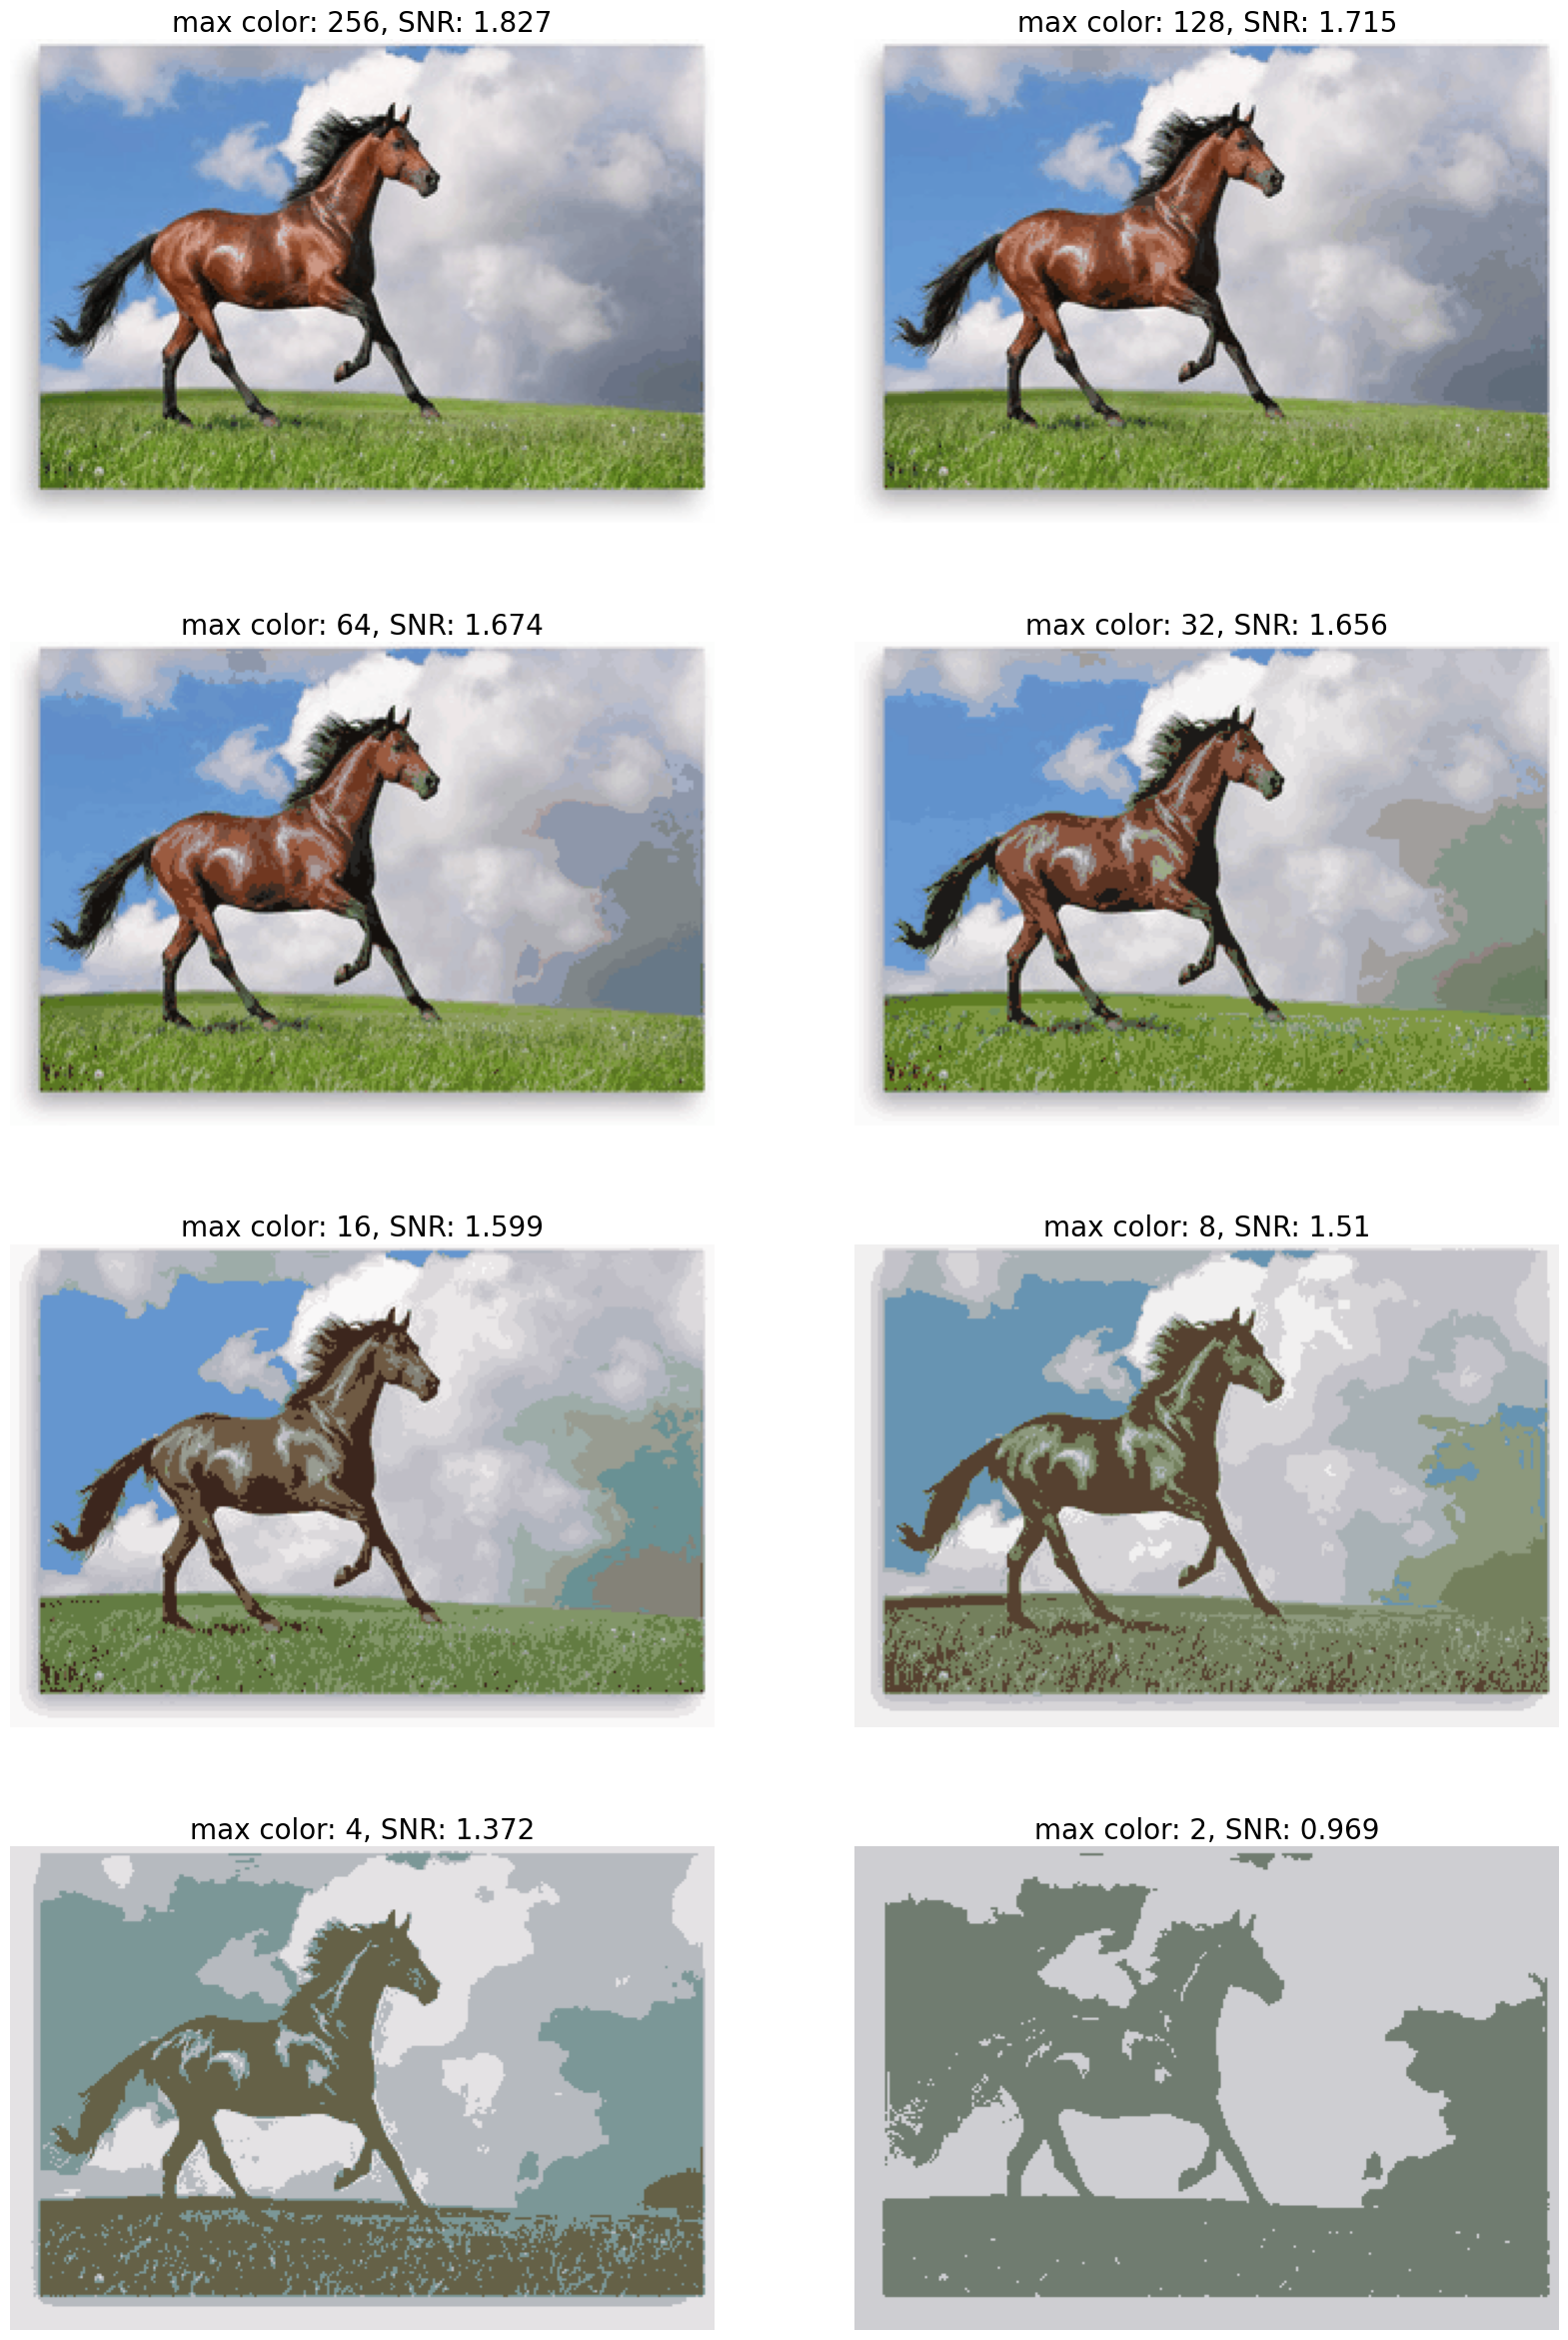

In [11]:
img = Image.open('../images-videos/horse.jpeg')
plt.figure(figsize=(20, 30))
snr_list = []
i = 1
num_colors_list = [1 << n for n in range(8, 0, -1)]
for num_colors in num_colors_list:
    img1 = img.convert(mode='P', palette=Image.ADAPTIVE, colors=num_colors)
    plt.subplot(4, 2, i), plt.imshow(img1), plt.axis('off')
    img1_array = np.array(img1)
    img_snr = calc_snr(img1_array)
    snr_list.append(img_snr)
    plt.title('max color: ' + str(num_colors) + ', SNR: ' + str(np.round(snr_list[i-1], 3)), size=20)
    i += 1
plt.show()

<p style="font-family:Bookman Old Style;font-size:24px">plot the impact of color-quantization on the SNR of the image</p>

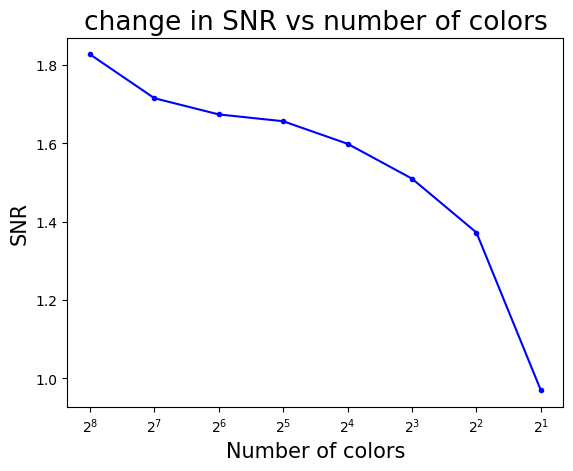

In [12]:
plt.plot(num_colors_list, snr_list, 'b.-')
plt.xlabel('Number of colors', size=15)
plt.ylabel('SNR', size=15)
plt.title('change in SNR vs number of colors', size=19)
plt.xscale('log', base=2)
plt.gca().invert_xaxis()
plt.show()